In [1]:
#!pip install -q git+https://github.com/sunsmarterjie/yolov12.git roboflow supervision flash-attn
!pip install roboflow
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 93.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 153.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.1 MB/s eta 0:00:00


In [2]:
import os, random, shutil, rasterio, torch

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

from rasterio.windows import Window
from rasterio.features import shapes
from rasterio.transform import Affine
from shapely.geometry import Polygon, MultiPolygon, box, shape

In [3]:
import os
from google.colab import userdata

os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")

In [4]:
!nvidia-smi

Tue Mar 17 09:57:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [6]:
from ultralytics import YOLO
from roboflow import Roboflow
rf = Roboflow(api_key="Wp24o55YexUp4lOqknub")
project = rf.workspace("segmentation-iugrk").project("crop-field-bopay")
version = project.version(3)
dataset = version.download("yolov11")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Crop-Field-3 in yolov11:: 100%|██████████| 648/648 [00:00<00:00, 7103.19it/s]


In [ ]:
# model = YOLO('yolov11n-seg.yaml')
model = YOLO('yolo11n-seg.yaml')
model = YOLO('yolo11n-seg.pt')

project = '/content/drive/MyDrive/AGRI/CropField_Segmentation/result'

name = 'yolov11n-seg-cropfield-100epoch-version01'

results = model.train(
    data=f'{dataset.location}/data.yaml',
    epochs=100,
    imgsz=640,

    # --- GPU utilization ---
    device=0,              # explicit GPU 0 (use '0,1' for multi-GPU)
    batch=16,              # larger batch fills GPU VRAM better; try 16→32→64
    workers=4,             # parallel dataloader workers feeding the GPU
    cache='ram',           # cache images in RAM → eliminates CPU I/O bottleneck

    # --- Mixed precision (2x throughput on Ampere/T4/A100) ---
    amp=True,              # automatic mixed precision (FP16) — huge speedup

    # --- Optimizer ---
    optimizer='AdamW',     # AdamW converges faster than default SGD
    lr0=0.001,
    cos_lr=True,           # cosine LR schedule — better final accuracy

    # --- Output ---
    project=project,
    task='segment',
    name=name,

    # --- Misc ---
    exist_ok=True,
    verbose=True,
)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/Crop-Field-3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov11n-seg-cropfield-100epoch-version01, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overla

In [8]:
model = YOLO('/content/drive/MyDrive/AGRI/CropField_Segmentation/result/yolov11n-seg-cropfield-100epoch-version01/weights/best.pt')

results = model.predict(
    source='/content/drive/MyDrive/AGRI/CropField_Segmentation/Screenshot 2026-03-17 063235.png',
    conf=0.10,        # confidence threshold
    iou=0.20,         # NMS IoU threshold
    imgsz=640,
    max_det=1000,
    save=True,        # saves annotated image
    save_dir='runs/predict'
)


image 1/1 /content/drive/MyDrive/AGRI/CropField_Segmentation/Screenshot 2026-03-17 063235.png: 512x640 37 fields, 60.9ms
Speed: 5.8ms preprocess, 60.9ms inference, 65.5ms postprocess per image at shape (1, 3, 512, 640)
Results saved to /content/runs/predict


In [9]:
for result in results:
    # Bounding boxes
    boxes = result.boxes
    print("Boxes (xyxy):", boxes.xyxy)       # coordinates
    print("Confidence:", boxes.conf)           # scores
    print("Classes:", boxes.cls)               # class ids

    # Segmentation masks
    if result.masks is not None:
        masks = result.masks.data             # (N, H, W) tensor
        xy_contours = result.masks.xy         # list of polygon contours
        print(f"Found {len(masks)} tree crowns")

    # Count detections
    print(f"Tree crowns detected: {len(result.boxes)}")

Boxes (xyxy): tensor([[7.3015e+02, 5.4077e+02, 1.0055e+03, 7.6494e+02],
        [4.8320e+02, 6.1797e+02, 7.6112e+02, 7.6597e+02],
        [4.4795e+02, 4.9192e+02, 7.0095e+02, 6.7317e+02],
        [6.6085e+02, 2.7189e+02, 1.0047e+03, 4.8063e+02],
        [5.1166e+02, 2.8516e+00, 9.2602e+02, 2.4823e+02],
        [2.9773e+02, 8.4789e+00, 5.0230e+02, 1.5306e+02],
        [1.9205e+02, 2.2916e+02, 3.8547e+02, 4.6193e+02],
        [1.6495e+02, 5.7180e+01, 3.0655e+02, 1.7102e+02],
        [4.8498e+02, 8.8817e-01, 6.8233e+02, 9.8944e+01],
        [3.2490e+02, 1.1036e+02, 5.4456e+02, 3.0773e+02],
        [4.0177e+01, 3.1653e+02, 2.0638e+02, 4.4995e+02],
        [2.2278e+02, 4.1989e+02, 4.1903e+02, 5.6980e+02],
        [4.1515e+02, 3.8845e+02, 6.6537e+02, 5.5554e+02],
        [4.2047e-01, 0.0000e+00, 1.1775e+02, 8.5748e+01],
        [9.0353e+02, 0.0000e+00, 1.0060e+03, 2.5382e+02],
        [5.0173e+01, 4.3656e+02, 2.2342e+02, 5.8397e+02],
        [2.7742e-01, 4.2664e+02, 4.3891e+01, 6.3220e+02],


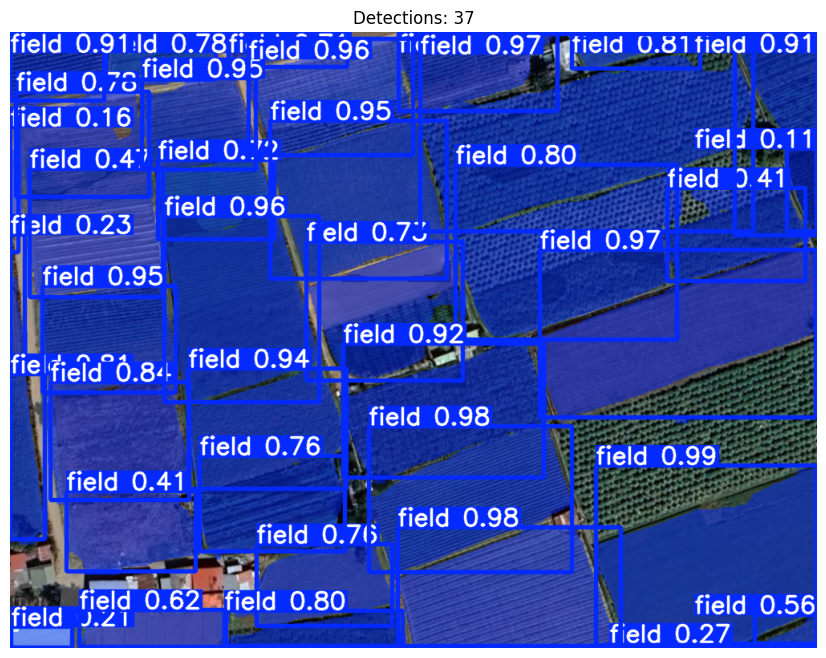

In [10]:
for result in results[:5]:  # show first 5
    img = result.plot()     # returns BGR numpy array with annotations
    img_rgb = img[:, :, ::-1]  # BGR -> RGB
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Detections: {len(result.boxes)}")
    plt.show()